# ***`Final Results`***
---
---
***Models:***
- Mistral
- LLama
- GPT-4o

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [8]:
df = pd.read_csv('../data/wmt-human_en_de_judged.csv').drop(
    columns=[
        'Unnamed: 0', 'id', 'source', 'reference', 'translation',
        'mean_human_score', 'individual_human_scores', 'n_annotations',
        'GPT-MINI_as_a_judge', 'MIXTRAL_as_a_judge',
    ]
)
print(df.shape)
df.head()

(9779, 6)


,human_#1,human_#2,human_#3,GPT_as_a_judge,MISTRAL_as_a_judge,LLAMA_as_a_judge
0,4,2,4,6,6,4
1,4,5,4,6,6,4
2,5,5,4,6,6,4
3,4,4,4,6,6,4
4,4,0,4,6,6,4


In [9]:
# human unique values
print(f"human #1 unique values: {df['human_#1'].unique()}")
print(f"human #2 unique values: {df['human_#2'].unique()}")
print(f"human #3 unique values: {df['human_#3'].unique()}")
print()
print("Mistral unique values: ", df['MISTRAL_as_a_judge'].unique())
print("LLAMA unique values: ", df['LLAMA_as_a_judge'].unique())
print("GPT-4o unique values: ", df['GPT_as_a_judge'].unique())

human #1 unique values: [4 5 3 6 2 1 0]
human #2 unique values: [2 5 4 0 6 3 1]
human #3 unique values: [4 1 2 5 3 6 0]

Mistral unique values:  ['6' '4' '5' '2' '6 (Perfect Meaning and Grammar)'
 '6 (The translation is perfect, as it is identical to the reference human translation.)'
 '0' 'Evaluation Error'
 '6 (The candidate translation is identical to the reference translation, so it receives a perfect score.)'
 '6 (The candidate translation is identical to the reference translation, so it is a perfect match.)']
LLAMA unique values:  ['4' '5' '3' 'Rating: 4' 'Rating: 5' '6' 'Evaluation Error' 'Rating: 3'
 '2']
GPT-4o unique values:  ['6' '5' '4' '3' '2' '0' 'Evaluation Error']


In [10]:
import re

def extract_valid_rating(series: pd.Series) -> pd.Series:
    """
    Extract leading number from strings in a Series,
    keeping only values between 0 and 6 inclusive.
    Non-matching or out-of-range values are returned as NaN.

    Parameters
    ----------
    series : pd.Series

    Returns
    -------
    pd.Series
        Series of integers in [0, 6] or NaN.
    """
    pattern = re.compile(r'^\s*(\d+)')

    values = []
    for item in series:
        text = str(item)
        match = pattern.match(text)
        if match:
            value = int(match.group(1))
            if 0 <= value <= 6:
                values.append(value)
            else:
                values.append(np.nan)
        else:
            values.append(np.nan)

    return pd.Series(values, index=series.index)

for col in df.columns:
    df[col] = extract_valid_rating(df[col])

print("Mistral unique values: ", df['MISTRAL_as_a_judge'].unique())
print("LLAMA unique values: ", df['LLAMA_as_a_judge'].unique())
print("GPT-4o unique values: ", df['GPT_as_a_judge'].unique())

Mistral unique values:  [ 6.  4.  5.  2.  0. nan]
LLAMA unique values:  [ 4.  5.  3. nan  6.  2.]
GPT-4o unique values:  [ 6.  5.  4.  3.  2.  0. nan]


In [11]:
# filter where nan
df.dropna(inplace=True)

# cast all to int
df = df.astype(int)

print(df.shape)

print()
print("Mistral unique values: ", df['MISTRAL_as_a_judge'].unique())
print("LLAMA unique values: ", df['LLAMA_as_a_judge'].unique())
print("GPT-4o unique values: ", df['GPT_as_a_judge'].unique())
print()

df.dtypes

(8135, 6)

Mistral unique values:  [6 4 5 2 0]
LLAMA unique values:  [4 5 3 6 2]
GPT-4o unique values:  [6 5 4 3 2 0]



human_#1              int64
human_#2              int64
human_#3              int64
GPT_as_a_judge        int64
MISTRAL_as_a_judge    int64
LLAMA_as_a_judge      int64
dtype: object

## ***`Diversity of Opinion`***
---

- initialize evaluator instance:

/Users/sebastianwefers/Desktop/LLM-as-a-Judge/LLM-as-a-Judge-good-enough/wmt-human/src/../../llm_good_enough/evaluator.py:223: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 2
  legend = ax.legend(


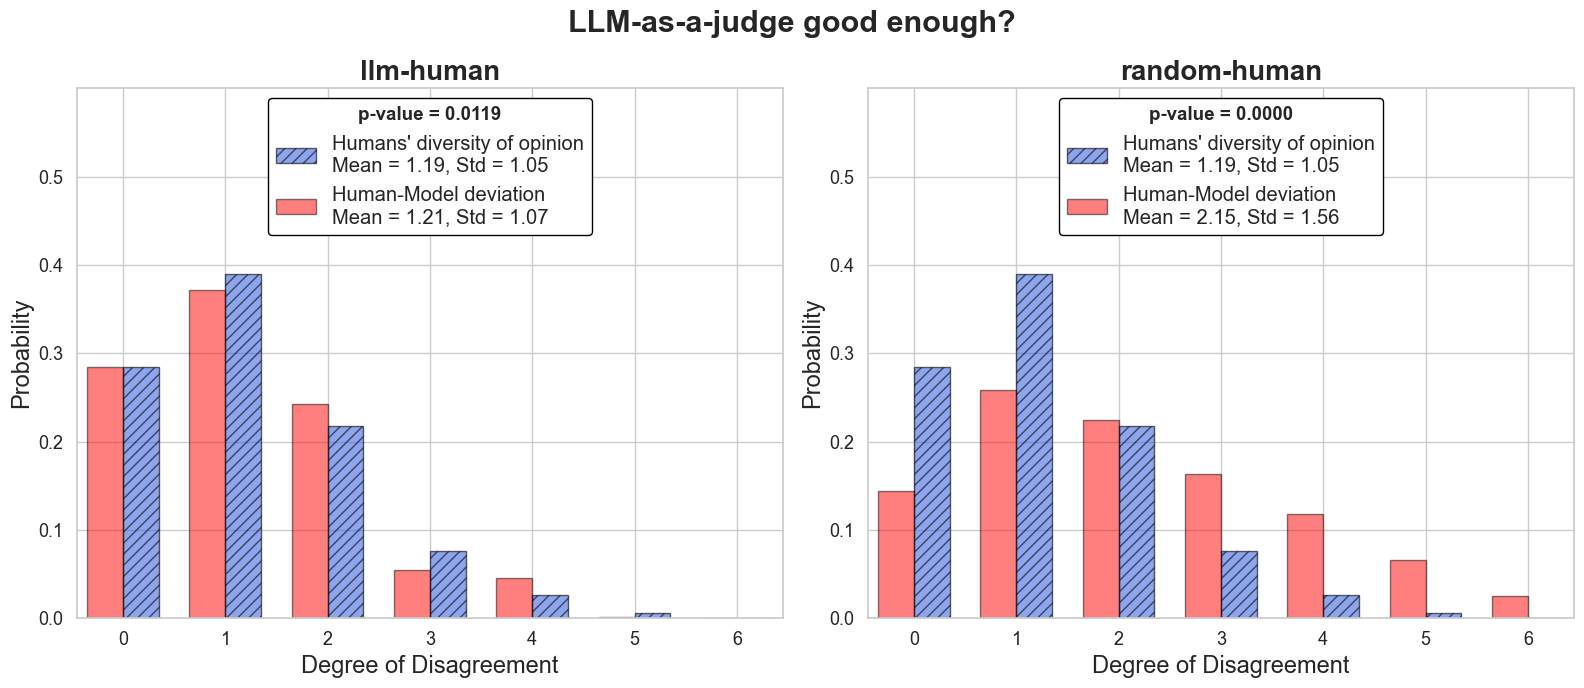

In [6]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..')) 

from llm_good_enough import LLMGoodEnough

human_cols = [col for col in df.columns if col.startswith('human_')]

LLM_Evaluator = LLMGoodEnough(df=df, human_cols=human_cols)

# visualize LLM-as-a-judge good enough
LLM_Evaluator.visulize_good_enough(llm_col='LLAMA_as_a_judge', min_score=0, max_score=6, y_lim=0.6)

### ***1. Human-Human Disagreement***

In [12]:
human_human_disagreements = LLM_Evaluator.compute_human_disagreements()

print(human_human_disagreements.shape)
# mean and std (=2 decimal places)
print(f"Mean: {round(human_human_disagreements.mean(), 2)}")
print(f"Std: {round(human_human_disagreements.std(), 2)}")

(24405,)
Mean: 1.19
Std: 1.05


### ***2. Human-LLM Disagreement***

In [ ]:
def compute_llm_human_disagreements(df: pd.DataFrame, human_cols: list[str], llm_col: str) -> np.ndarray:
    """
    Vectorized computation of absolute differences between LLM and each human judge per case.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing ratings.
    human_cols : list of str
        Column names for human judges.
    llm_col : str
        Column name for the LLM judge's ratings.

    Returns
    -------
    np.ndarray
        Array of absolute differences (LLM vs. each human) across all cases.
    """
    if len(human_cols) < 2:
        raise ValueError("❌ At least two human columns are required.")

    # if nan in df raise error
    if df.isna().any().any():
        raise ValueError("❌ Data contains NaN values.")

    # Drop rows with any missing values in required columns
    required_cols = human_cols + [llm_col]
    filtered_df = df.dropna(subset=required_cols)

    # Convert to NumPy arrays
    human_ratings = filtered_df[human_cols].to_numpy()
    llm_ratings = filtered_df[llm_col].to_numpy().reshape(-1, 1)  # column vector for broadcasting

    # Compute absolute differences: each human col vs. LLM
    differences = np.abs(human_ratings - llm_ratings)

    return differences.flatten()

In [14]:
# print shapes, mean and std (=2 decimal places)
print(f"LLAMA:")
llama_human_disagreements = LLM_Evaluator.compute_llm_human_disagreements('LLAMA_as_a_judge')
print(f"   - Shape: {llama_human_disagreements.shape}")
print(f"   - Mean: {round(llama_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(llama_human_disagreements.std(), 3)}")
print()

print(f"MISTRAL:")
mistral_human_disagreements =  LLM_Evaluator.compute_llm_human_disagreements('MISTRAL_as_a_judge')
print(f"   - Shape: {mistral_human_disagreements.shape}")
print(f"   - Mean: {round(mistral_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(mistral_human_disagreements.std(), 3)}")
print()

print(f"GPT-4o:")
gpt4o_human_disagreements = LLM_Evaluator.compute_llm_human_disagreements('GPT_as_a_judge')
print(f"   - Shape: {gpt4o_human_disagreements.shape}")
print(f"   - Mean: {round(gpt4o_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(gpt4o_human_disagreements.std(), 3)}")

LLAMA:
   - Shape: (24405,)
   - Mean: 1.21
   - Std: 1.066

MISTRAL:
   - Shape: (24405,)
   - Mean: 1.812
   - Std: 1.418

GPT-4o:
   - Shape: (24405,)
   - Mean: 1.575
   - Std: 1.246


### 3. ***Human-Random Judge Disagreement***


In [15]:
import random

# set seed for reproducibility
random.seed(42)

MIN, MAX = 0, 6

# compute random judge
df['RANDOM_as_a_judge'] = np.random.randint(MIN, MAX + 1, size=len(df))

# compute human-random judge disagreement
human_random_disagreements = LLM_Evaluator.compute_llm_human_disagreements('RANDOM_as_a_judge')

# print shapes, mean and std (=2 decimal places)
print(f"RANDOM:")
print(f"   - Shape: {human_random_disagreements.shape}")
print(f"   - Mean: {round(human_random_disagreements.mean(), 3)}")
print(f"   - Std: {round(human_random_disagreements.std(), 3)}")

RANDOM:
   - Shape: (24405,)
   - Mean: 2.158
   - Std: 1.556


### ***`Results`***
---

- *`Null hypothesis (H₀):`* The LLM–human disagreement distribution is not worse than the human–human disagreement distribution.
- *`Alternative hypothesis (H₁):`* The LLM–human disagreement is greater (i.e., worse aligned) than human–human disagreement.

***From the paper:***

- “... test the hypothesis that the probability to find a bigger value in HJ (LLM-Human) than in HD (Human-Human) is as high as finding a smaller one.”
- “We use mannwhitneyu(x=HJ, y=HD, alternative='greater')”

In [16]:
from scipy.stats import mannwhitneyu

# compute mann-whitney u test and round to 4 decimal places
llama_human_pvalue = mannwhitneyu(
    llama_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue
print(f"LLAMA vs. Human: {round(llama_human_pvalue, 4)}")

gpt4o_human_pvalue = mannwhitneyu(
    gpt4o_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"GPT-4o vs. Human: {round(gpt4o_human_pvalue, 4)}")

mistral_human_pvalue = mannwhitneyu(
    mistral_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"MISTRAL vs. Human: {round(mistral_human_pvalue, 4)}")

random_human_pvalue = mannwhitneyu(
    human_random_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"RANDOM vs. Human: {round(random_human_pvalue, 4)}")

LLAMA vs. Human: 0.0119
GPT-4o vs. Human: 0.0
MISTRAL vs. Human: 0.0
RANDOM vs. Human: 0.0


/var/folders/5g/s374b1pn0s96jnh30yczkw480000gn/T/ipykernel_50784/2238766155.py:43: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 2
  legend = ax.legend(


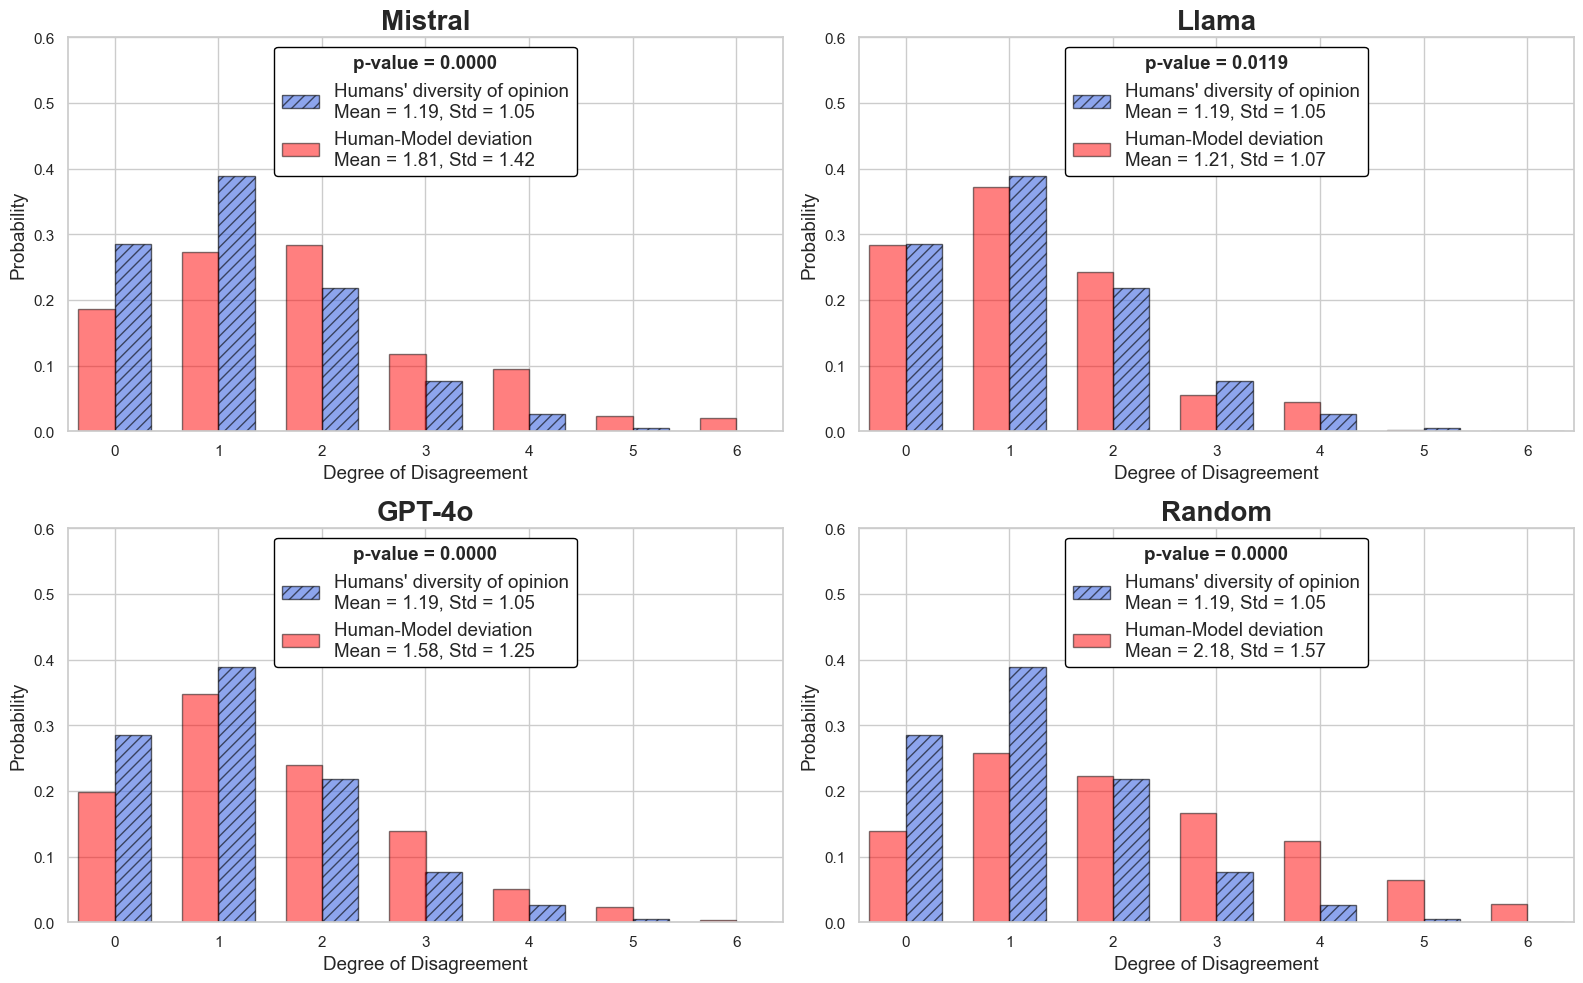

In [11]:
# Compute statistics
def stats_and_p(distribution):
    mean = round(np.mean(distribution), 2)
    std = round(np.std(distribution), 2)
    p = mannwhitneyu(distribution, human_human_disagreements, alternative='greater').pvalue
    return mean, std, p

models = {
    'Mistral': mistral_human_disagreements,
    'Llama': llama_human_disagreements,
    'GPT-4o': gpt4o_human_disagreements,
    'Random': human_random_disagreements
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

bins = np.arange(0, 8)  # For disagreement values 0–6
bar_width = 0.35
categories = np.arange(len(bins) - 1)

for ax, (name, data) in zip(axes, models.items()):
    mean_model, std_model, p_val = stats_and_p(data)
    mean_human = round(np.mean(human_human_disagreements), 2)
    std_human = round(np.std(human_human_disagreements), 2)

    # Plot human-human
    ax.hist(human_human_disagreements, bins=bins, density=True, alpha=0.6, color='royalblue',
            label=f"Humans' diversity of opinion\nMean = {mean_human}, Std = {std_human}",
            width=bar_width, edgecolor='black', hatch="///")

    # Plot model-human
    ax.hist(data, bins=bins - 0.35, density=True, alpha=0.5, color='red',
            label=f'Human-Model deviation\nMean = {mean_model}, Std = {std_model}',
            width=bar_width, edgecolor='black', hatch="")


    # Add p-value to legend
    handles, labels = ax.get_legend_handles_labels()
    handles.append(plt.Line2D([], [], color='none'))
    #labels.append(f'   p-value: {p_val:.5f}')

    legend = ax.legend(
        handles=handles, labels=labels, loc='upper center', title=f"p-value = {p_val:.4f}",
        edgecolor='black', facecolor='white', framealpha=1,
        fontsize=13.5
        )
    legend.get_title().set_fontweight('bold')
    # title fontsize 20
    legend.get_title().set_fontsize(13.5)


    ax.set_title(name, fontweight='bold', fontsize=20)
    ax.set_xlabel('Degree of Disagreement', fontsize=13.5)
    ax.set_ylabel('Probability', fontsize=13.5)
    ax.set_xticks(categories)
    ax.set_xlim(min(categories) - bar_width - 0.1, max(categories) + bar_width + 0.1)
    ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show();